# 04_204 · Transformer jerárquico multitarea con cuatro categorías

Variante reproducible de `04_5`. Un solo encoder comparte una cabeza binaria `SEGURO`/daño y una cabeza multietiqueta con `RACISMO_DISCRIMINACION`, `ACOSO_GENERO_IDENTIDAD`, `ACOSO_AMENAZA` y `CONTENIDO_SEXUAL`. El score operativo es `p(daño) × p(categoría | representación)`.

`ACOSO_AMENAZA` fusiona acoso personal y amenaza directa. Por defecto se inicia desde el Transformer de `04_2` seleccionado únicamente con validation; todas las cabezas se vuelven a optimizar y los umbrales se recalibran.

El arranque híbrido usa el workspace en local y, en Colab, código fijado de GitHub con artefactos mínimos persistentes en Google Drive.

In [1]:
from pathlib import Path
from importlib.util import find_spec
import json, os, shutil, subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

REPO_URL = 'https://github.com/lkoc/Trabajo_PLN-MIA-Grupo4.git'
GIT_COMMIT = 'ce33b5efd797eef0809e9ff8694c90220cd81e9d'
PROJECT_NAME, DRIVE_BUNDLE_NAME, NEEDS_PEFT = 'Trabajo_PLN-MIA-Grupo4', 'PLN_colab_04_artifacts', False

def _bootstrap_04_20x():
    in_colab = find_spec('google.colab') is not None
    if not in_colab:
        start = Path.cwd().resolve()
        root = next((p for p in (start, *start.parents) if (p / 'scripts_auxiliares').is_dir()), None)
        if root is None: raise FileNotFoundError('No se encontró la raíz local del proyecto.')
        return root, False, root, 'working-tree-local'
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    artifacts = Path('/content/drive/MyDrive') / DRIVE_BUNDLE_NAME
    manifest_path = artifacts / 'MANIFIESTO_ARTEFACTOS_04_20X.json'
    if not manifest_path.is_file(): raise FileNotFoundError('Falta el bundle de Drive; ejecute sincronizar_04_20x_google_drive.ps1 en Windows.')
    manifest = json.loads(manifest_path.read_text(encoding='utf-8-sig'))
    missing = [r['path'] for r in manifest['files'] if not (artifacts / r['path']).is_file()]
    if missing: raise FileNotFoundError('Bundle incompleto en Drive:\n' + '\n'.join(missing))
    root = Path('/content') / PROJECT_NAME
    if not (root / '.git').is_dir():
        if root.exists(): raise RuntimeError(f'Ruta no administrada ya existente: {root}')
        subprocess.run(['git', 'clone', '--filter=blob:none', '--no-checkout', REPO_URL, str(root)], check=True)
    current = subprocess.check_output(['git', '-C', str(root), 'rev-parse', 'HEAD'], text=True).strip()
    if current != GIT_COMMIT:
        subprocess.run(['git', '-C', str(root), 'fetch', '--depth', '1', 'origin', GIT_COMMIT], check=True)
    subprocess.run(['git', '-C', str(root), 'sparse-checkout', 'set', 'scripts_auxiliares'], check=True)
    subprocess.run(['git', '-C', str(root), 'checkout', '--detach', GIT_COMMIT], check=True)
    for name in ('datos', 'modelos', 'resultados'):
        local, target = root / name, artifacts / name
        target.mkdir(parents=True, exist_ok=True)
        if local.is_symlink() and local.resolve() == target.resolve(): continue
        if local.is_symlink(): local.unlink()
        elif local.exists(): raise RuntimeError(f'Ruta de artefactos no administrada: {local}')
        local.symlink_to(target, target_is_directory=True)
    return root, True, artifacts, GIT_COMMIT

ROOT, IN_COLAB, ARTIFACT_ROOT, CODE_VERSION = _bootstrap_04_20x()
if IN_COLAB:
    packages = {'transformers': 'transformers>=4.51,<6', 'sklearn': 'scikit-learn>=1.4'}
    if NEEDS_PEFT: packages['peft'] = 'peft>=0.15,<1'
    missing_packages = [p for m, p in packages.items() if find_spec(m) is None]
    if missing_packages: subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *missing_packages], check=True)
os.environ['PLN_PROJECT_ROOT'], os.environ['PLN_ARTIFACT_ROOT'] = str(ROOT), str(ARTIFACT_ROOT)
os.chdir(ROOT)
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

from scripts_auxiliares import experimentos_jerarquicos_4 as h4

print('Entorno:', 'Google Colab híbrido' if IN_COLAB else 'local')
print('Código:', ROOT, CODE_VERSION)
print('Artefactos persistentes:', ARTIFACT_ROOT)
print('Dispositivo:', h4.device())
print('Objetivos:', h4.TARGET_LABELS)

Mounted at /content/drive
Entorno: Google Colab híbrido
Código: /content/Trabajo_PLN-MIA-Grupo4 ce33b5efd797eef0809e9ff8694c90220cd81e9d
Artefactos persistentes: /content/drive/MyDrive/PLN_colab_04_artifacts
Dispositivo: cuda
Objetivos: ['RACISMO_DISCRIMINACION', 'ACOSO_GENERO_IDENTIDAD', 'ACOSO_AMENAZA', 'CONTENIDO_SEXUAL']


## 1. Datos congelados e inicialización

El experimento conserva exactamente los train/validation/test de `04_2`. El hash del dataset, manifiesto, checkpoint plano y scores se valida antes de entrenar. La referencia y el inicio se eligen por PR-AUC macro de cuatro daños en validation; test no interviene.

In [2]:
context = h4.load_frozen_context()
display(h4.context_summary(context))
display(h4.warm_start_plan(context))

counts = pd.DataFrame({
    split: h4.four_targets(frame).sum(axis=0).astype(int)
    for split, frame in context['frames'].items()
}, index=h4.TARGET_LABELS)
display(counts)

,split,chunks,videos,con_daño,seguros,chunk_ids_sha256
0,train,24701,2086,4944,19757,9132a1678e24c9bb29d06fcbc1a44d8fb0c54737e571fe...
1,validation,5324,448,1078,4246,571e3e1b829ce1ee2a2f7143bddd99bca67833389b9f47...
2,test,5290,448,1041,4249,9c9c1880e5aa1573754562e1054cc8796e235a99fa4256...


{'enabled_by_default': True,
 'selected_by_validation': 'e5_small',
 'selected_model_label': 'Multilingual E5-small (linaje MiniLM) · unión post hoc a cuatro daños',
 'validation_damage_pr_auc_macro_four_labels': 0.5208643228699481,
 'checkpoint': {'path': 'modelos/moderador_transformer_grueso/e5_small/best_checkpoint.pt',
  'sha256': '8220c22d92304547d26b8b05f245c2347f75570ae4e2f04337207328e3a6ef5d',
  'bytes': 470707208},
 'reuse': {'encoder': 'copied from the selected 04_2 checkpoint',
  'unchanged_category_rows': [0, 1, 4],
  'ACOSO_AMENAZA_row': 'mean of former rows 2 and 3; retrained afterwards',
  'binary_head': 'random unless a compatible old hierarchical checkpoint exists',
  'thresholds': 'never reused; recalibrated on validation'},
 'old_hierarchical_checkpoints_present': {'binary_gate': [],
  'conditional_categories': [],
  'joint_hierarchical': []}}

,train,validation,test
RACISMO_DISCRIMINACION,1319,281,256
ACOSO_GENERO_IDENTIDAD,1394,304,263
ACOSO_AMENAZA,2077,488,463
CONTENIDO_SEXUAL,1613,334,335


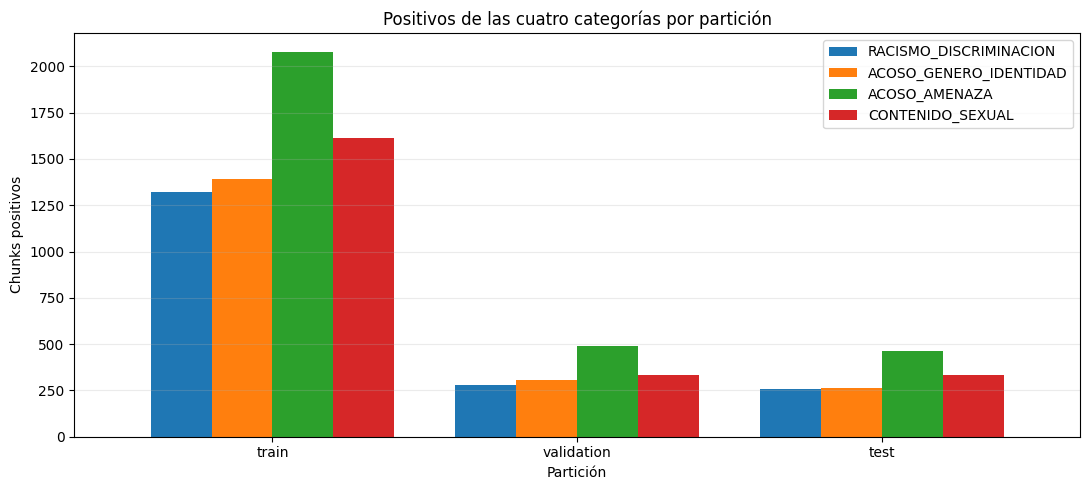

In [3]:
ax = counts.T.plot.bar(figsize=(11, 5), width=0.8)
ax.set_title('Positivos de las cuatro categorías por partición')
ax.set_ylabel('Chunks positivos')
ax.set_xlabel('Partición')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Diseño multitarea y transferencia

El modelo optimiza simultáneamente: pérdida binaria para cualquier daño, pérdida multietiqueta para cuatro daños y una penalización de consistencia cuando una categoría supera a la probabilidad global de daño. Las ponderaciones positivas usan la raíz de `negativos/positivos`, evitando aplicar el cociente completo bajo desbalance. La cabeza binaria ve todo `SEGURO` permitido por el aislamiento de videos; la pérdida de categorías queda enmascarada en esos negativos adicionales y continúa usando sólo el train 4:1.

El encoder parte del E5 ya afinado en `04_2`. Las filas de racismo, género y sexual se copian; `ACOSO_AMENAZA` se inicializa con el promedio de las antiguas filas de acoso y amenaza. La cabeza binaria se inicializa aleatoriamente. Todas estas piezas se actualizan durante el nuevo entrenamiento. Si más adelante existe un checkpoint terminado de `04_5` con el mismo dataset y encoder, se reutilizarán además su encoder y cabeza binaria, adaptando la cabeza de categorías.

La referencia plana combina las antiguas probabilidades como `max(p_acoso, p_amenaza)` y recalibra cuatro umbrales en validation. El máximo evita suponer independencia entre las dos salidas. La evaluación final usa bootstrap pareado por videos sobre el mismo test.

In [4]:
WARM_START = True
FORCE = False
BOOTSTRAP_REPLICATES = 1_000

print({
    'warm_start': WARM_START,
    'force': FORCE,
    'bootstrap_replicates': BOOTSTRAP_REPLICATES,
})

{'warm_start': True, 'force': False, 'bootstrap_replicates': 1000}


## 3. Reentrenamiento conjunto

La celda presenta avance por época, inferencia y bootstrap. Guarda el mejor checkpoint según PR-AUC macro de daño en validation, el historial por época, scores, umbrales, reportes, figuras, comparación y un informe Markdown. Con `FORCE=False`, un resultado compatible ya concluido sólo se carga.

In [5]:
result = h4.run_joint_experiment(
    force=FORCE,
    bootstrap_replicates=BOOTSTRAP_REPLICATES,
    warm_start=WARM_START,
)
display({
    'experimento': result['experiment_label'],
    'inicializacion': result['training']['initialization'],
    'datos_entrenamiento': result['training']['training_data'],
    'mejor_epoca': result['training']['best_epoch'],
    'decision': result['decision'],
})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

Jerárquico época 3: PR-AUC macro=0.4358; F1 macro=0.4314; PR-AUC binaria=0.6948


jerárquico conjunto · validation:   0%|          | 0/167 [00:00<?, ?lote/s]

jerárquico conjunto · test:   0%|          | 0/166 [00:00<?, ?lote/s]

bootstrap pareado por video:   0%|          | 0/1000 [00:00<?, ?réplica/s]

{'experimento': 'Transformer jerárquico multitarea → cuatro daños',
 'inicializacion': {'enabled': True,
  'role': 'joint_hierarchical',
  'strategy': 'warm_start_from_04_2_flat_transformer',
  'source': {'path': 'modelos/moderador_transformer_grueso/e5_small/best_checkpoint.pt',
   'sha256': '8220c22d92304547d26b8b05f245c2347f75570ae4e2f04337207328e3a6ef5d',
   'bytes': 470707208},
  'source_epoch': 3,
  'copied': ['domain_finetuned_backbone', 'mapped_category_head'],
  'head_merge': 'mean of ACOSO_PERSONAL and AMENAZA_DIRECTA rows',
  'random_components': ['binary_head']},
 'datos_entrenamiento': {'purpose': 'expanded_binary_supervision_with_masked_category_loss',
  'selection': 'all integrated SEGURO excluding validation/test videos',
  'integrated_dataset': 'datos/model_ready/transformer_grueso/dataset_integrado_todas_pasadas.jsonl',
  'integrated_dataset_sha256': '3f01b76d285d4cdd2a0922df1d2437a7f01abc4e05e2699c218b1f5faaba2069',
  'matched_train_rows': 24701,
  'matched_train_saf

,epoch,training_loss,validation_binary_pr_auc,validation_damage_pr_auc_macro,validation_damage_f1_macro,thresholds
0,1,0.610318,0.678948,0.398107,0.390823,"[0.39999999999999997, 0.27499999999999997, 0.0..."
1,2,0.552909,0.696149,0.420956,0.382554,"[0.39999999999999997, 0.125, 0.05, 0.125]"
2,3,0.432418,0.694789,0.435777,0.431363,"[0.42499999999999993, 0.22499999999999998, 0.0..."


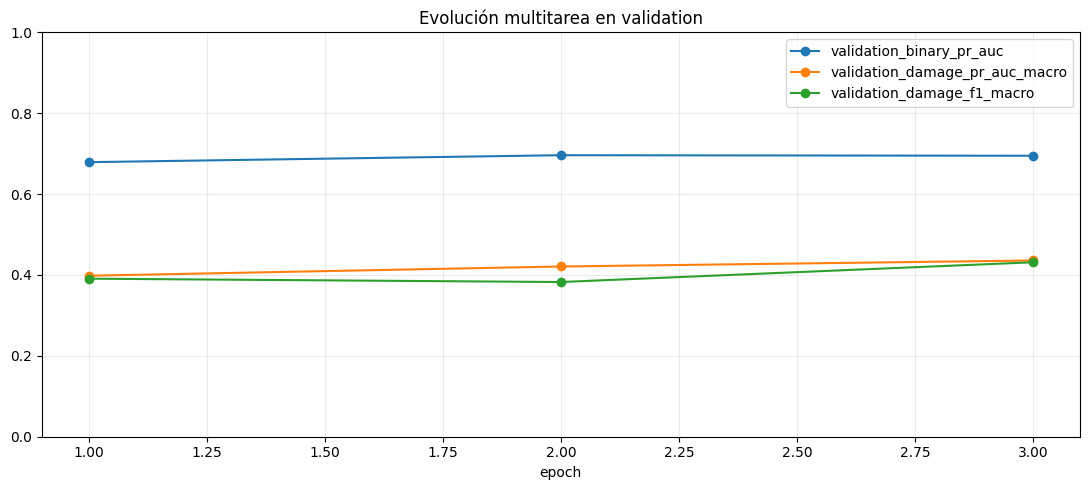

In [6]:
history = pd.DataFrame(result['training']['history'])
display(history)
ax = history.plot(
    x='epoch',
    y=['validation_binary_pr_auc', 'validation_damage_pr_auc_macro', 'validation_damage_f1_macro'],
    marker='o',
    figsize=(11, 5),
)
ax.set_title('Evolución multitarea en validation')
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Resultados, incertidumbre y uso operativo

La arquitectura sólo reemplaza la referencia plana si todo el IC 95% del delta de PR-AUC macro es positivo sin aumentar falsos negativos. También se informa una política selectiva de auto-seguro, alerta/revisión y auto-daño, calibrada exclusivamente en validation.

,split,modelo,damage_pr_auc_macro,damage_f1_macro,damage_recall_micro,any_damage_recall,minimum_category_recall,missed_damage_as_safe,category_false_negatives
0,validation,Multilingual E5-small (linaje MiniLM) · unión ...,0.520864,0.535226,0.520256,0.653989,0.450820,373,675
1,validation,Transformer jerárquico multitarea → cuatro daños,0.435777,0.431363,0.351102,0.368275,0.305328,681,913
2,test,Multilingual E5-small (linaje MiniLM) · unión ...,0.491340,0.515280,0.529233,0.636888,0.460043,378,620
3,test,Transformer jerárquico multitarea → cuatro daños,0.413376,0.424805,0.372058,0.395773,0.332613,629,827


,categoria,positivos_test,precision_plano,recall_plano,f1_plano,pr_auc_plano,falsos_negativos_plano,precision_experimento,recall_experimento,f1_experimento,pr_auc_experimento,falsos_negativos_experimento,delta_recall,delta_pr_auc
0,RACISMO_DISCRIMINACION,256,0.460123,0.585938,0.515464,0.479415,106,0.627737,0.335938,0.437659,0.381645,170,-0.250000,-0.097770
1,ACOSO_GENERO_IDENTIDAD,263,0.459930,0.501901,0.480000,0.433822,131,0.456897,0.403042,0.428283,0.384003,157,-0.098859,-0.049819
2,ACOSO_AMENAZA,463,0.402647,0.460043,0.429435,0.393045,250,0.301370,0.332613,0.316222,0.350592,309,-0.127430,-0.042452
3,CONTENIDO_SEXUAL,335,0.673333,0.602985,0.636220,0.659078,133,0.648649,0.429851,0.517056,0.537266,191,-0.173134,-0.121812


,metrica,plano_test,experimento_test,delta_experimento_menos_plano,ic95_inferior,ic95_superior,replicas_validas
0,pr_auc_macro,0.491340,0.413376,-0.077963,-0.098151,-0.054582,1000
1,f1_macro,0.515280,0.424805,-0.090475,-0.112733,-0.066214,1000
2,any_damage_recall,0.636888,0.395773,-0.241114,-0.270932,-0.210628,1000
3,false_negative_rate,0.363112,0.604227,0.241114,0.210628,0.270932,1000


,calibration_partition,validation_recall_target_for_auto_safe,validation_precision_target_for_auto_damage,low_auto_safe_threshold,high_auto_damage_threshold,validation,n,auto_safe_rows,auto_damage_rows,review_rows,automatic_coverage,review_rate,damage_sent_to_review_or_auto_damage_recall,damage_automatic_safe_false_negatives,damage_automatic_safe_false_negative_rate,safe_sent_to_review
0,validation,0.97,0.9,0.005714,0.938196,"{'n': 5324, 'auto_safe_rows': 1808, 'auto_dama...",5290,1874,249,3167,0.401323,0.598677,0.970221,31,0.029779,2373


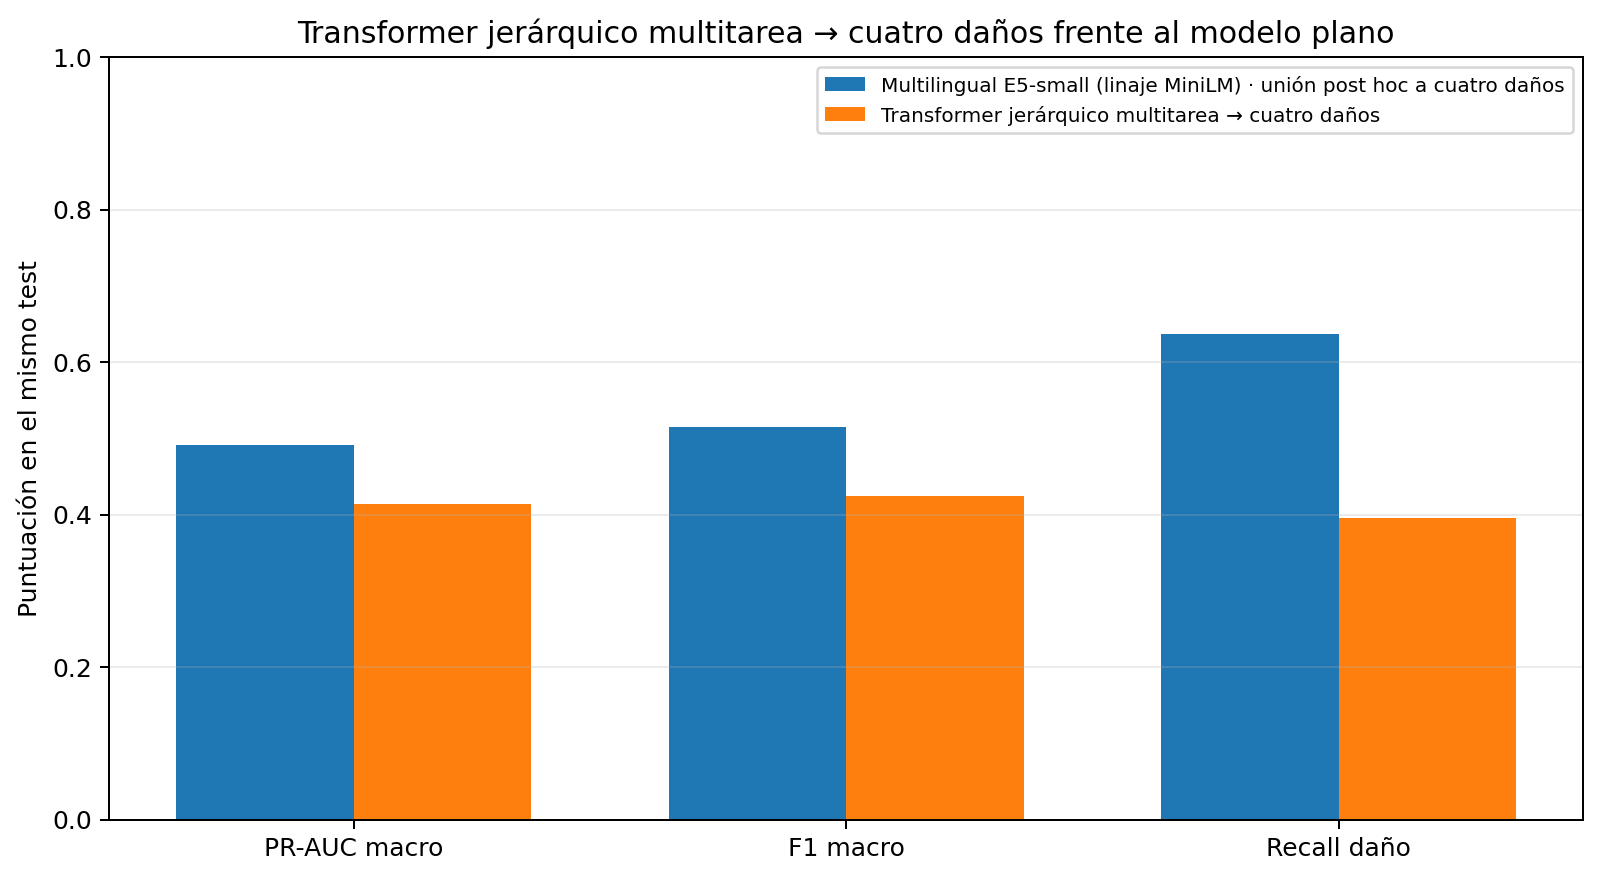

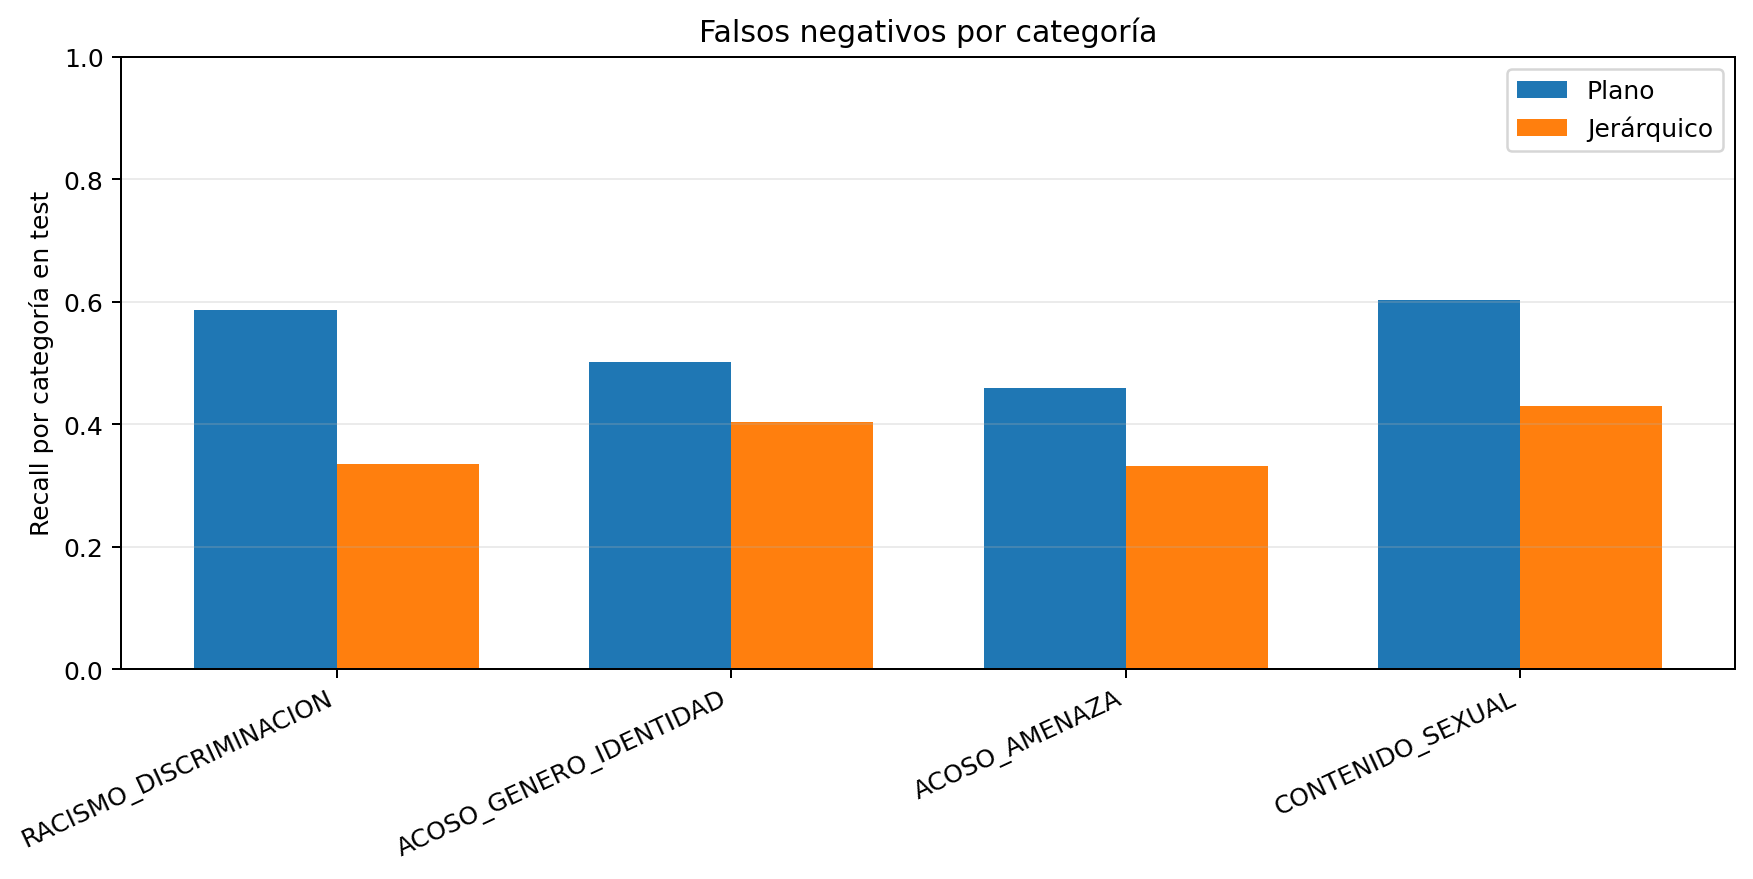

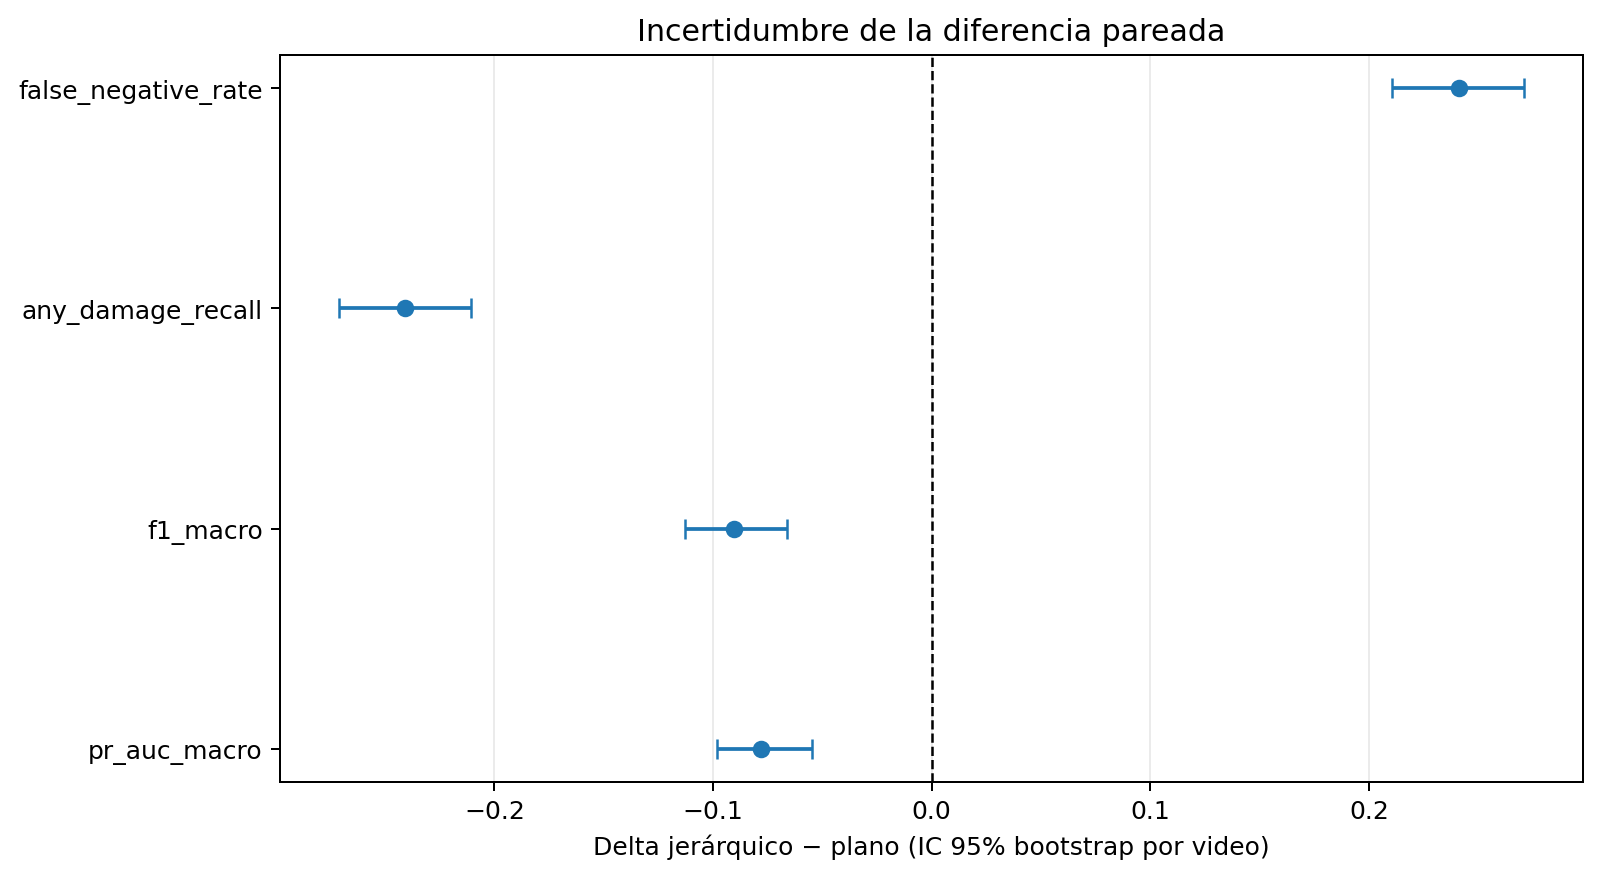

In [7]:
tables = h4.load_experiment_tables(h4.JOINT_KEY)
display(tables['comparison'])
display(tables['categories'])
display(tables['bootstrap'])
display(pd.DataFrame([result['selective_operation']]))

figure_dir = h4.FIGURES_ROOT / h4.JOINT_KEY
for name in ['comparacion_global_test.png', 'recall_por_categoria_test.png', 'bootstrap_deltas_test.png']:
    display(Image(filename=str(figure_dir / name)))

In [8]:
display(Markdown(
    f'**Resultado reproducible:** `{h4.result_path(h4.JOINT_KEY).relative_to(ROOT)}`  \n'
    f'**Informe:** `{h4.report_path(h4.JOINT_KEY).relative_to(ROOT)}`  \n'
    f'**Modelo:** `{(h4.MODEL_ROOT / h4.JOINT_KEY).relative_to(ROOT)}`'
))

**Resultado reproducible:** `resultados/metricas/experimentos_jerarquicos_4/transformer_jerarquico_multitarea_4/resultado.json`  
**Informe:** `resultados/INFORME_04_204_JERARQUICO_MULTITAREA_4_ETIQUETAS.md`  
**Modelo:** `modelos/experimentos_jerarquicos_4/transformer_jerarquico_multitarea_4`

## Referencias (APA 7)

Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079–2107. https://www.jmlr.org/papers/v11/cawley10a.html

Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall/CRC.

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432

Zhou, J., Ma, C., Long, D., Xu, G., Ding, N., Zhang, H., Xie, P., & Liu, G. (2020). Hierarchy-aware global model for hierarchical text classification. In *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics* (pp. 1106–1117). Association for Computational Linguistics. https://doi.org/10.18653/v1/2020.acl-main.104